<a href="https://colab.research.google.com/github/rmndrs89/advanced-time-series-prediction/blob/main/2_BaselineModel/Time_Series_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss

In [ ]:
# !pip install sktime[all_extras] -qq

In [2]:
DATASET_PATH = Path("/content/drive/MyDrive/Colab Notebooks/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

In [3]:
def load_file(file_path: Path) -> tuple[np.ndarray, float]:

    # Load the data into a numpy ndarray
    with open(file_path, "rb") as infile:
        arr = np.load(infile)

    # Extract the accelerometer data as the input features
    features = arr[:, 1:4]

    # Extract the labels
    labels = arr[:, 4:]
    labels = np.max(labels, axis=-1)
    return features, np.any(labels).astype(float)

In [4]:
loaded_arr = np.load("/content/drive/MyDrive/Colab Notebooks/tdcsfog/train/003f117e14_0000.npy")
print(loaded_arr[0])

dftrain = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tdcsfog/train.csv')
dftrain.head()

[ 0.         -9.5339393   0.56632163 -1.41352531  0.          0.
  0.        ]


,file_name,label
0,76c7edf878_0004.npy,1.0
1,e7b5afe544_0014.npy,1.0
2,76c7edf878_0011.npy,1.0
3,2a9faf5644_0000.npy,0.0
4,5a70242f37_0002.npy,1.0


In [5]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset



def load_windowed_data_with_label(folder_path, rolling_window=5):
    X = []
    y = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".npy"):
            arr = np.load(os.path.join(folder_path, filename))  # shape: (window_len, 7)

            features = arr[:, 1:4]    # 3 original features (acc_x, acc_y, acc_z)
            labels = arr[:, 4:]      # last 3 columns = FoG levels

            # Convert to DataFrame for rolling
            df_feat = pd.DataFrame(features, columns=['acc_x', 'acc_y', 'acc_z'])

            # Add rolling average columns (window=5)
            for col in df_feat.columns:
                df_feat[f'{col}_avg'] = df_feat[col].rolling(window=rolling_window, min_periods=1).mean()

            features_with_avg = df_feat.to_numpy()  # shape: (1280, 6)

            # Create label: if any row in any of the 3 FoG columns has 1
            label = int(np.any(labels > 0))

            X.append(features_with_avg)
            y.append(label)

    return np.array(X), np.array(y)

In [6]:
X, y = load_windowed_data_with_label(TRAIN_PATH)



from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [7]:
X_test, y_test = load_windowed_data_with_label(TEST_PATH)

In [8]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3308, 1280, 6), (3308,), (960, 1280, 6), (960,))

In [13]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # (3308, 7680)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)    # (960, 7680)
X_train_flat.shape, y_train.shape, X_test_flat.shape, y_test.shape

((3308, 7680), (3308,), (960, 7680), (960,))

In [14]:
model = RandomForestClassifier(n_estimators=50, max_depth=10)

In [15]:
model.fit(X_train_flat, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50)

In [18]:
y_pred = model.predict(X_test_flat)

In [24]:
def evaluate_on_test(model, X_test_flat):
    y_pred = model.predict(X_test_flat)
    y_true = y_test
    # Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    print("Test Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))
    # print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format=".2f")
    plt.grid(False)
    plt.show()


    # Optionally return if needed
    return y_true, y_pred



Test Accuracy: 0.709375
Precision: 0.625
Recall: 0.7069408740359897
F1 Score: 0.6634499396863691
Confusion Matrix:



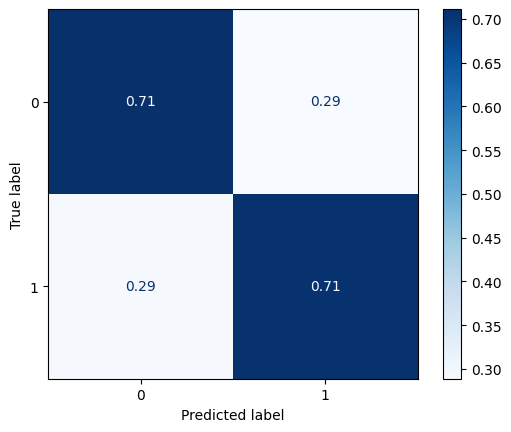

In [26]:
y_true ,y_pred =evaluate_on_test(model, X_test_flat)


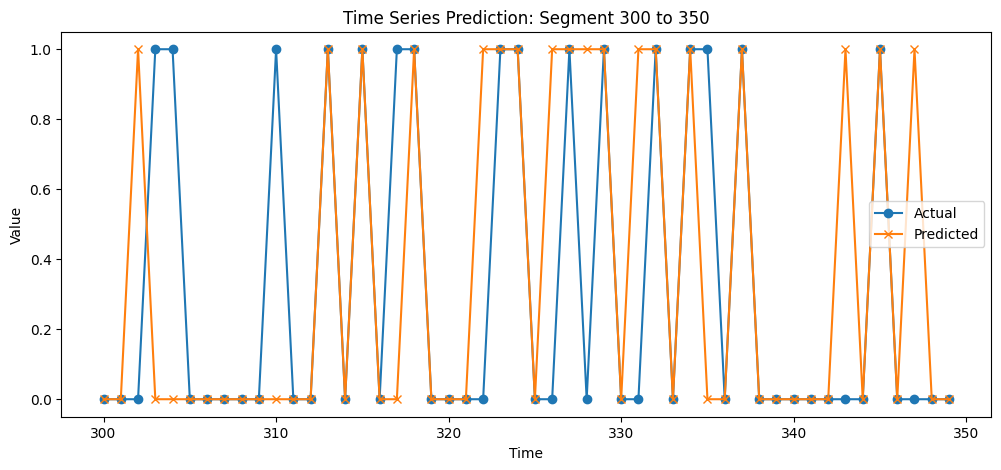

In [27]:
start = 300  # Starting index of segment
end = 350    # Ending index (exclusive)

# If y_true, y_pred are numpy arrays or lists:
time_segment = np.arange(start, end)
y_true_segment = y_true[start:end]
y_pred_segment = y_pred[start:end]

plt.figure(figsize=(12,5))
plt.plot(time_segment, y_true_segment, label='Actual', marker='o')
plt.plot(time_segment, y_pred_segment, label='Predicted', marker='x')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Time Series Prediction: Segment {start} to {end}')
plt.legend()
plt.show()
